**Rough Heston model**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from ssr.utils import non_uniform_grid, set_matplotlib_style
from ssr.data import get_params, get_xi0_interpolator, DATES
from ssr.rough_heston import RoughHestonModel, get_params_rough_heston

set_matplotlib_style()
SEED = 1234
SAVEFIG = False

# SSR expansions

In [20]:
# parameters
date = DATES[1]
print(f"Using parameters from {date}")

# model
model = "rough_heston"
kind_interp = "cubic"
xi0 = get_xi0_interpolator(date, model, kind=kind_interp)
params = get_params(date=date, model=model)
n_pade = 5
n_quad = 20

rheston = RoughHestonModel(params=params, xi0=xi0)
rheston

Using parameters from 2024-08-05


RoughHestonModel with parameters:
H=0.17, kappa=1.69, eta=0.53, rho=-0.99, s0=1.0

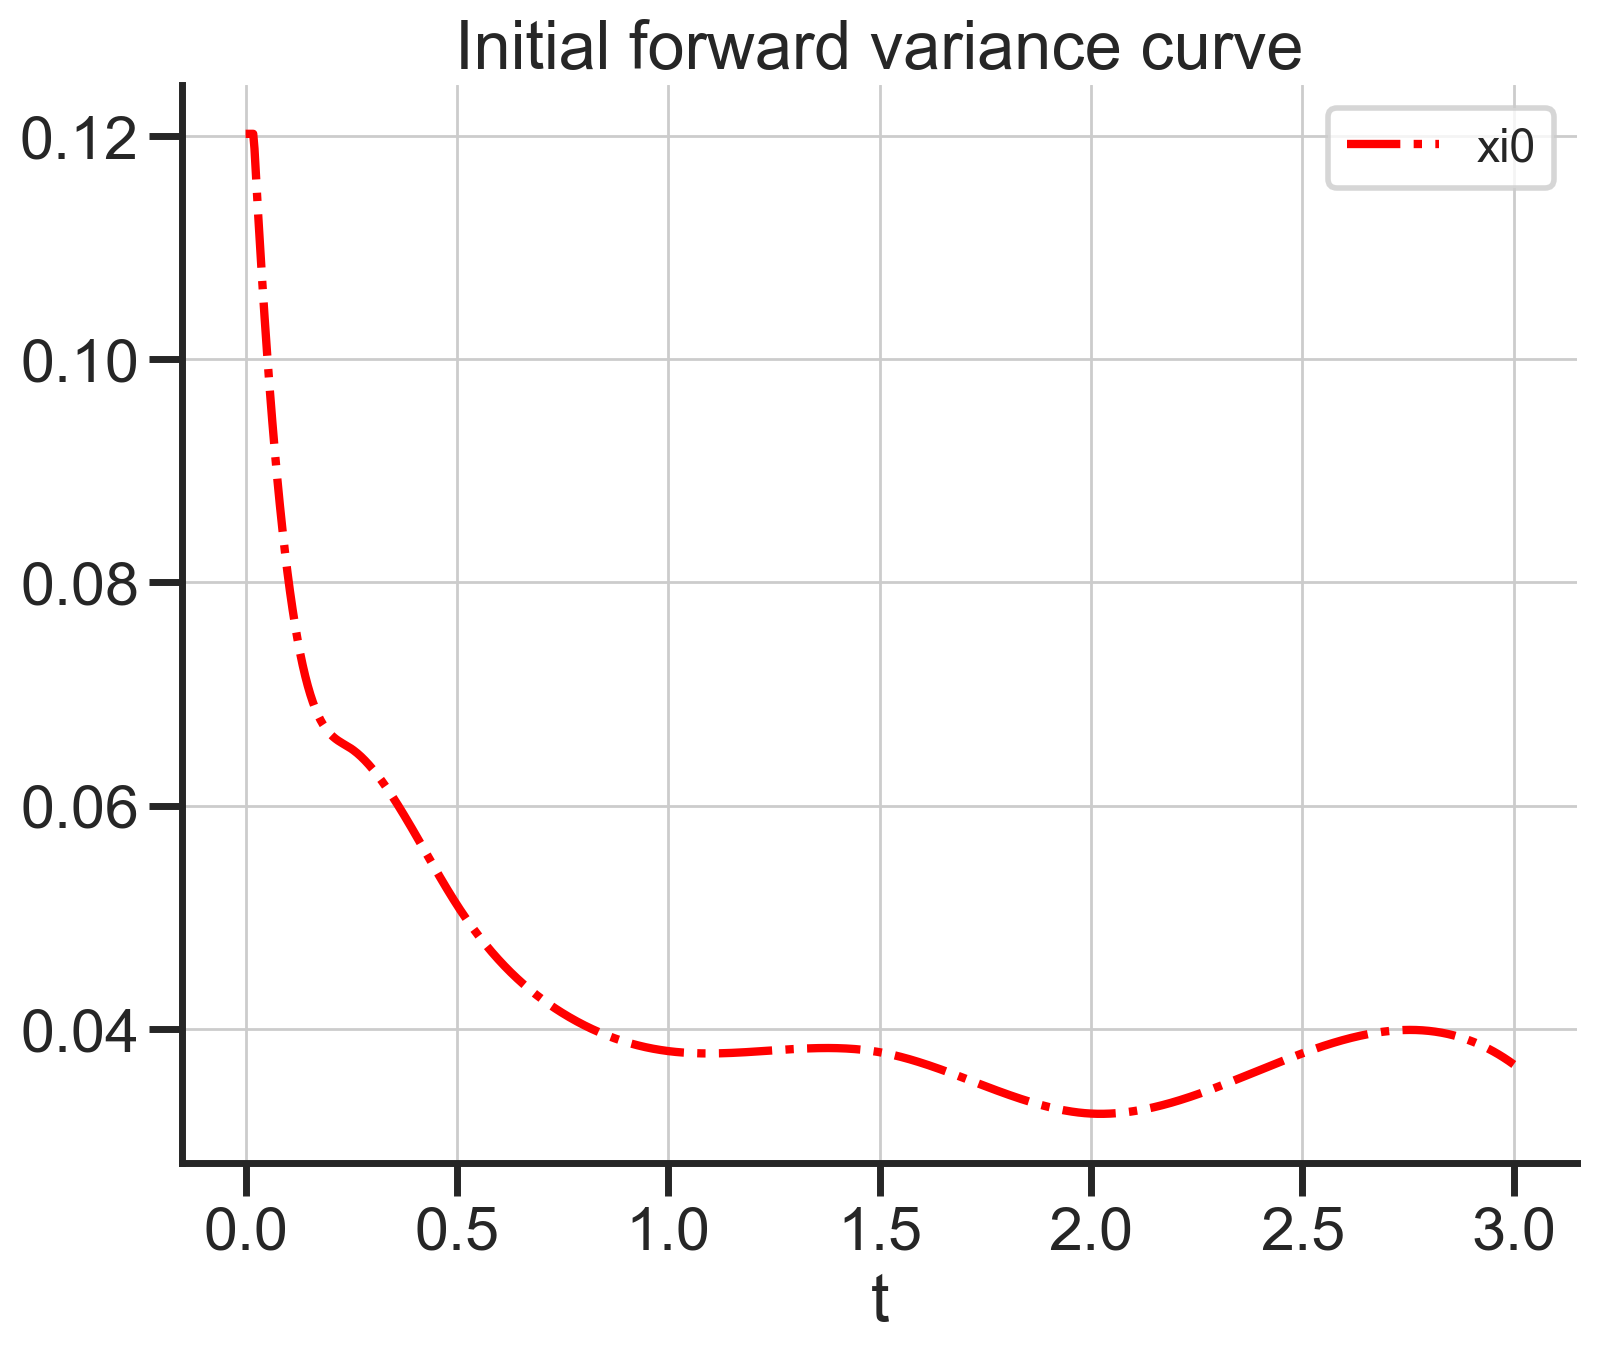

In [21]:
# xi0

us = np.linspace(0.0, 3.0, 1000)
fig, ax = plt.subplots()
ax.plot(us, xi0(us), "r-.", label="xi0")
ax.set_xlabel("t")
ax.set_title("Initial forward variance curve")
ax.legend()
plt.show()

In [22]:
# compute true beta, atm skew and SSRs
Ts = non_uniform_grid(a=7.0 / 365.0, b=3.0, n=15, power=1.5)
out = rheston.ssr_all(Ts, n_pade=n_pade, n_quad=n_quad)

In [23]:
# compute beta, atm skew and SSRs via BG expansion
Ts_bg = np.linspace(1e-3, 3, 200)
out_bg = rheston.ssr_bg_all(Ts_bg, n_pade=n_pade, n_quad=n_quad)

## Plots

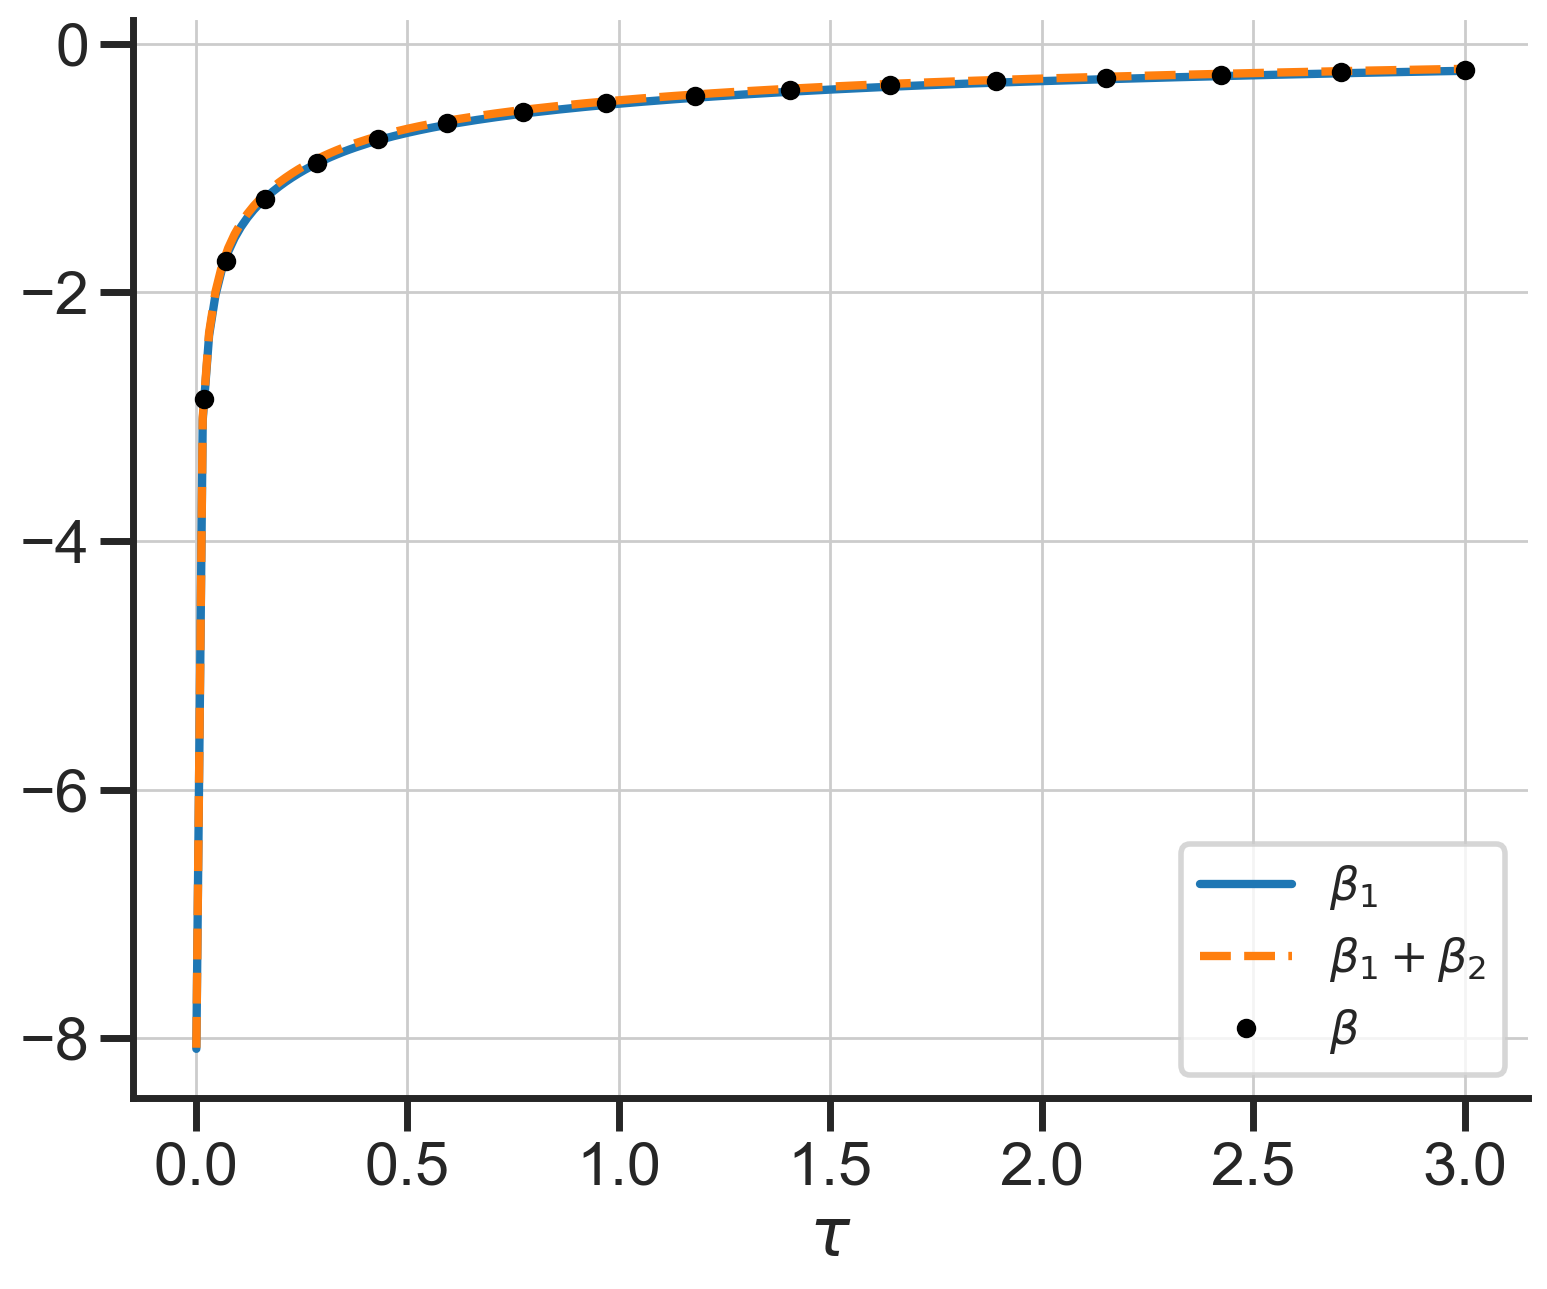

In [24]:
# plot beta
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["beta_1"], "-", label=r"$\beta_1$")
ax.plot(Ts_bg, out_bg["beta_1"] + out_bg["beta_2"], "--", label=r"$\beta_1+\beta_2$")
ax.plot(Ts, out["beta"], ".k", label=r"$\beta$")
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/rheston/rheston_{date}_beta.pdf", bbox_inches="tight")
plt.show()

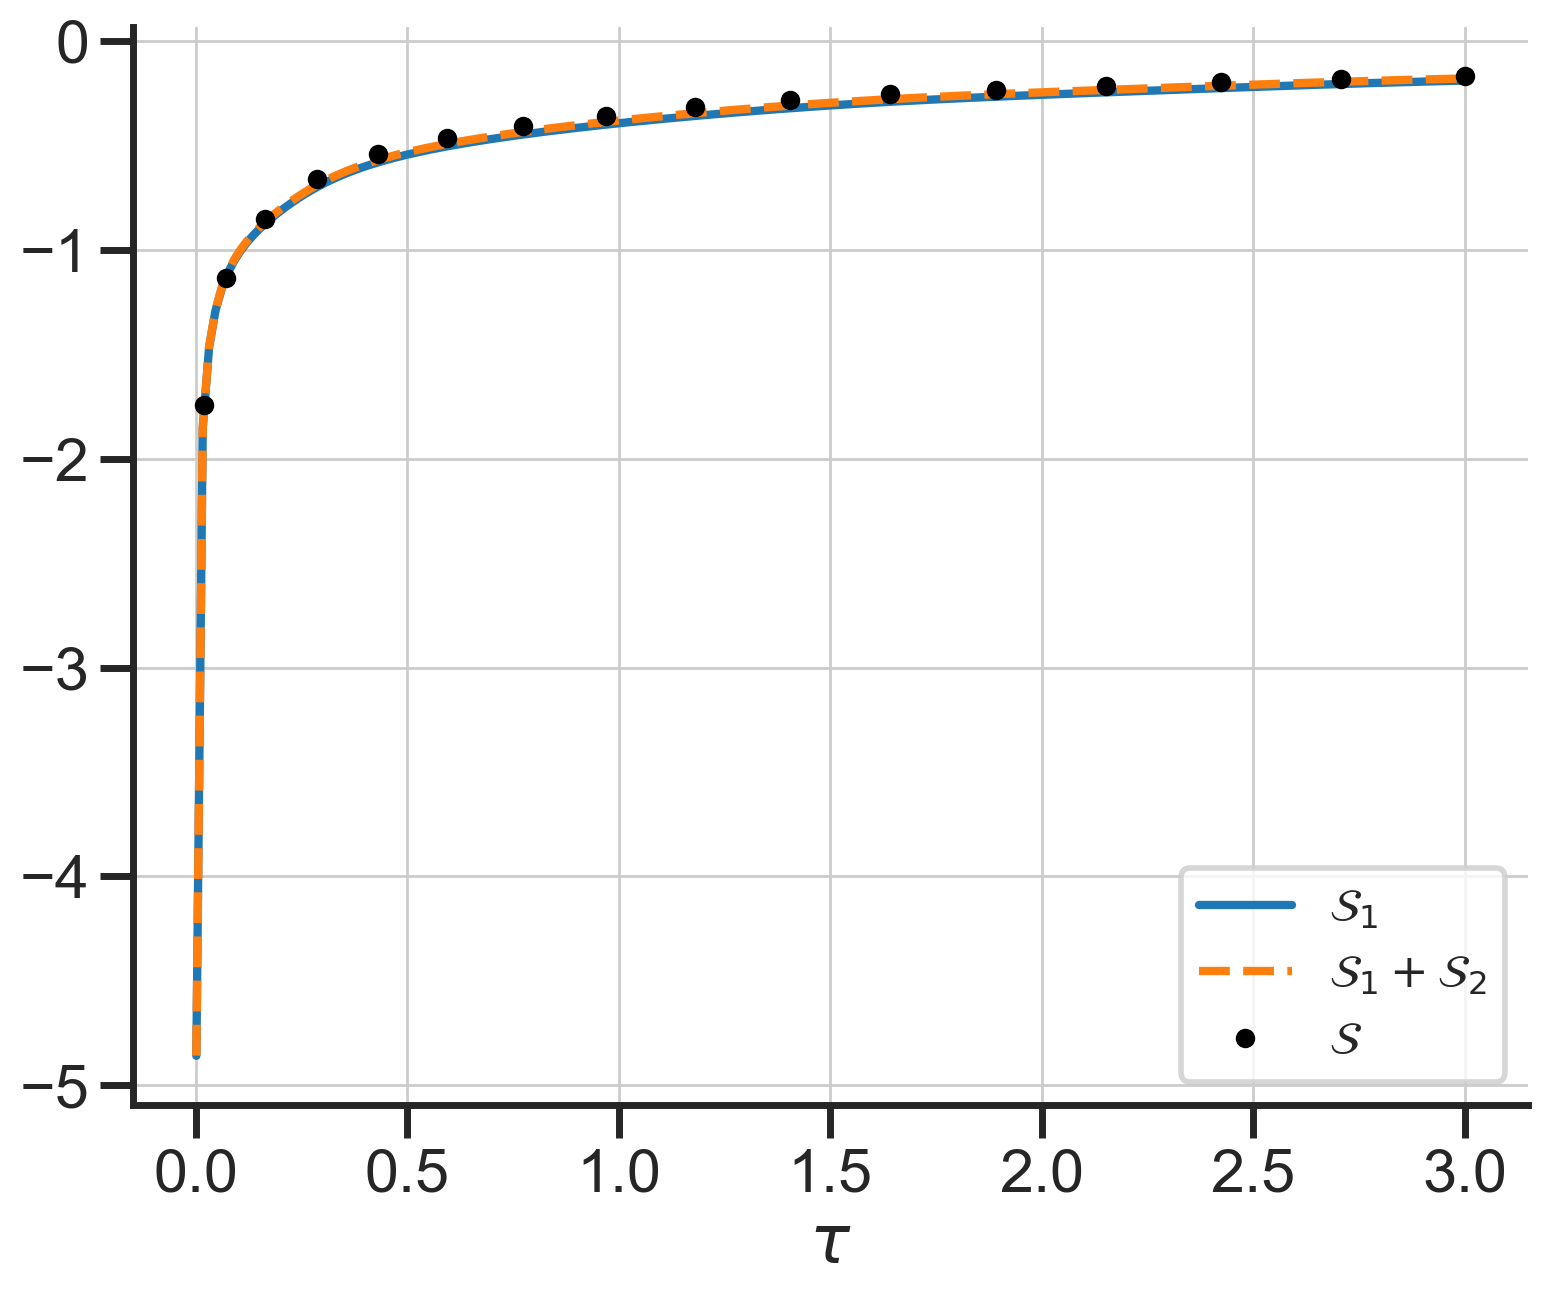

In [25]:
# plot ATM skew
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["atm_skew_1"], "-", label=r"$\mathcal{S}_1$")
ax.plot(
    Ts_bg,
    out_bg["atm_skew_1"] + out_bg["atm_skew_2"],
    "--",
    label=r"$\mathcal{S}_1+\mathcal{S}_2$",
)
ax.plot(Ts, out["atm_skew"], ".k", label=r"$\mathcal{S}$")
ax.legend()
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/rheston/rheston_{date}_atm_skew.pdf", bbox_inches="tight")
plt.show()

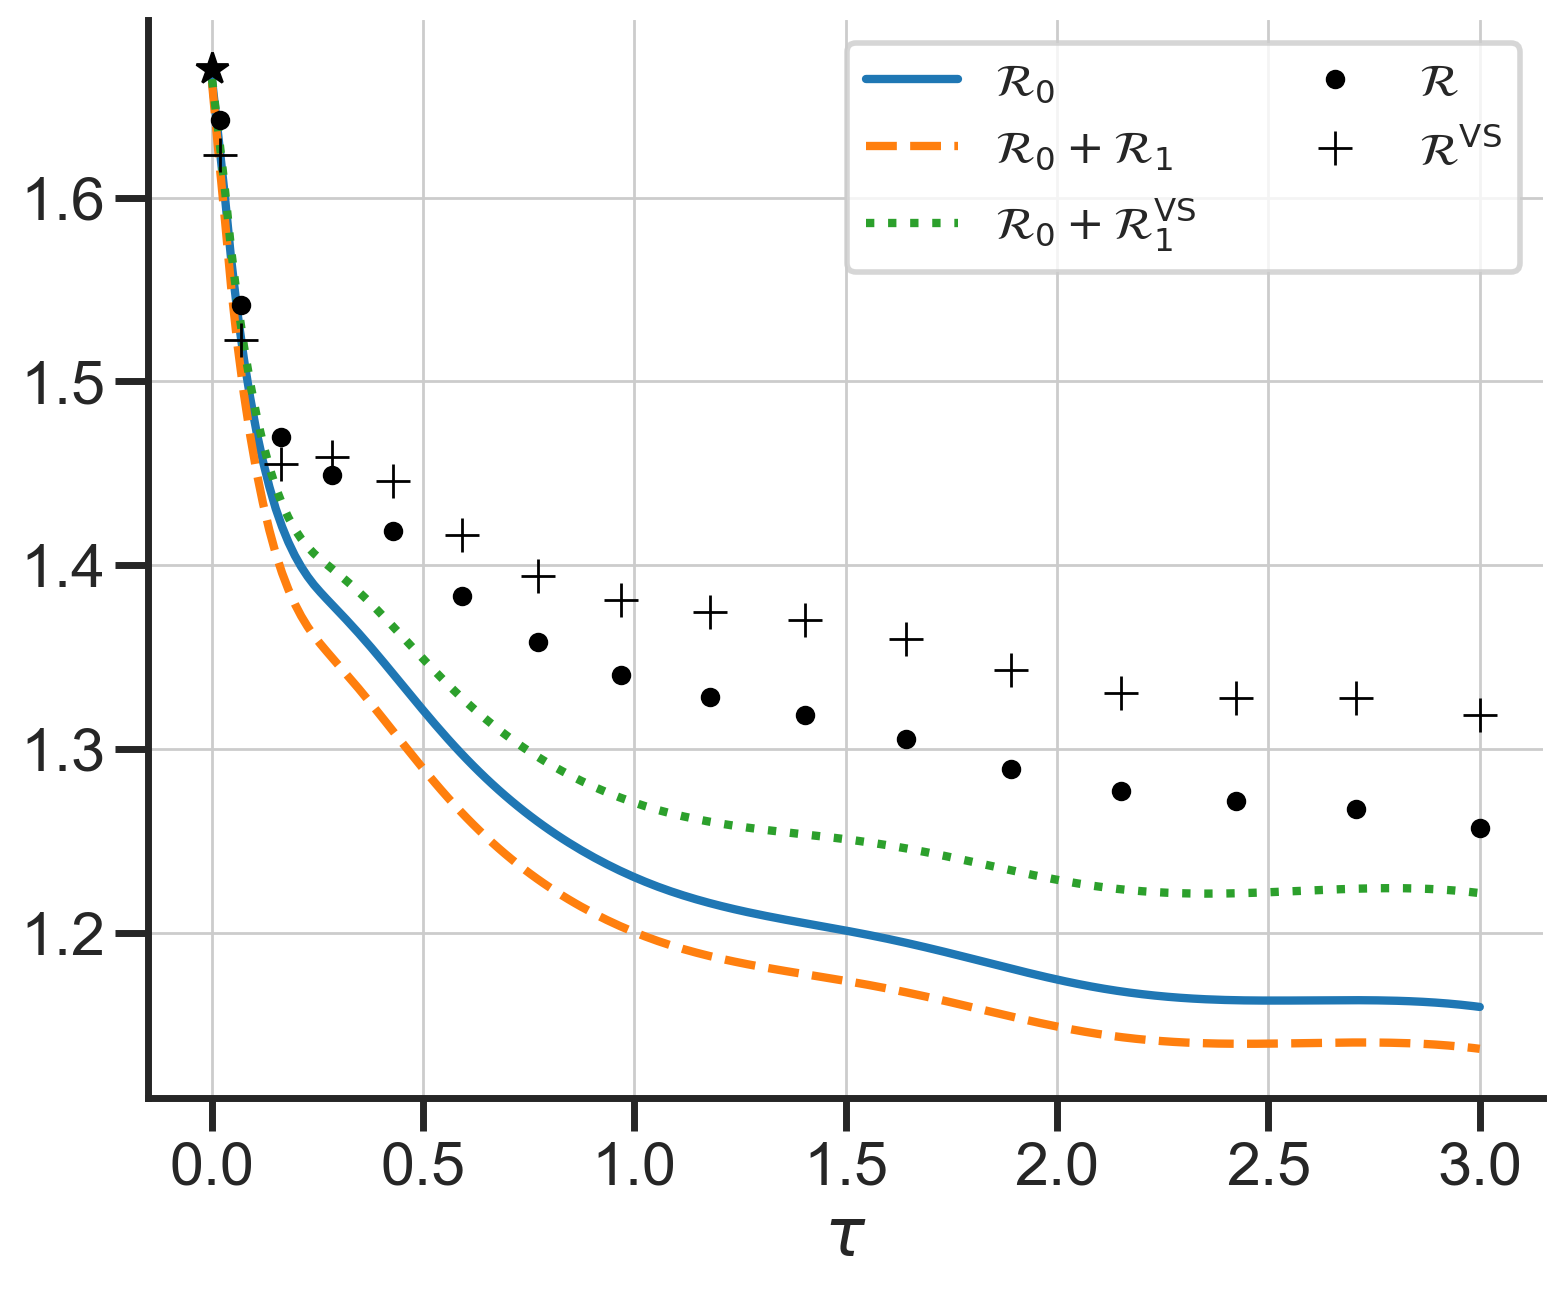

In [26]:
# plot SSR and VS SSR
fig, ax = plt.subplots()
ax.plot(Ts_bg, out_bg["ssr_0"], "-", label=r"$\mathcal{R}_0$")
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_1"],
    "--",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1$",
)
ax.plot(
    Ts_bg,
    out_bg["ssr_0"] + out_bg["ssr_vs_1"],
    ":",
    label=r"$\mathcal{R}_0 + \mathcal{R}_1^{\text{VS}}$",
)
ax.plot(Ts, out["ssr_cf"], ".k", label=r"$\mathcal{R}$")
ax.plot(Ts, out["ssr_vs"], "+k", label=r"$\mathcal{R}^{\text{VS}}$")
ax.plot([0], [rheston.H + 3 / 2], "*k")
ax.legend(ncol=2)
ax.set_xlabel(r"$\tau$")
if SAVEFIG:
    fig.savefig(f"figures/rheston/rheston_{date}_ssr.pdf", bbox_inches="tight")
plt.show()

# Checks

## General

In [27]:
params, xi0 = get_params_rough_heston(id=1)
params["H"] = 0.4
rheston = RoughHestonModel(params=params, xi0=xi0)
rheston

RoughHestonModel with parameters:
eta=0.4, H=0.4, kappa=1.0, rho=-0.65, s0=1.0

In [28]:
n_pade = 5
n_quad = 50
Ts = non_uniform_grid(1e-2, 3, 15, 2)

In [29]:
# atm skew
atm_skew_fd = rheston.atm_skew_fd(Ts, n_pade=n_pade, n_quad=n_quad, eps=1e-4)

In [30]:
atm_skew_cf = rheston.atm_skew_cf(Ts, n_pade=n_pade, n_quad=n_quad)

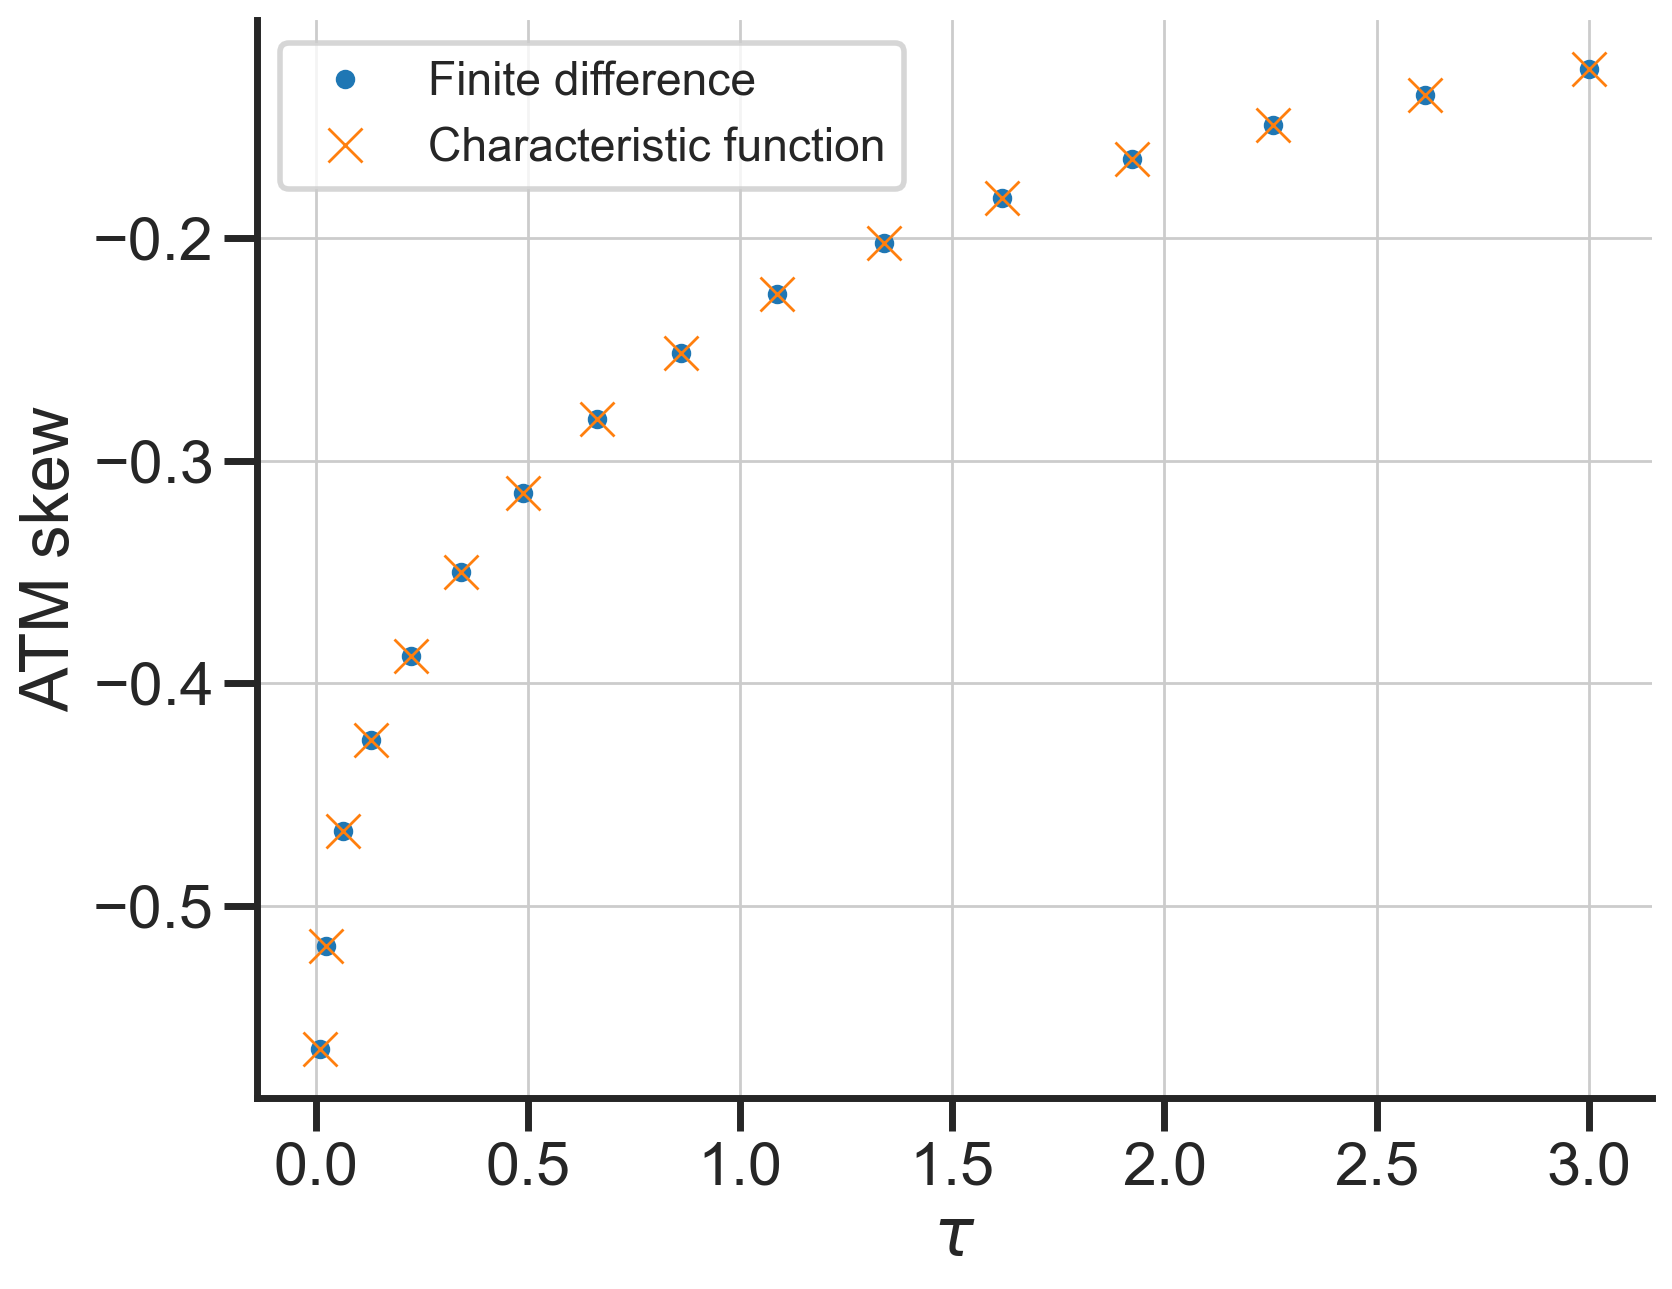

In [31]:
fig, ax = plt.subplots()
ax.plot(Ts, atm_skew_fd, ".", label="Finite difference")
ax.plot(Ts, atm_skew_cf, "x", label="Characteristic function")
ax.legend()
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("ATM skew")
plt.show()

In [32]:
# SSR
ssr_fd = rheston.ssr_fd(Ts, n_pade=n_pade, n_quad=n_quad, eps=1e-5)

In [33]:
ssr_cf = rheston.ssr_cf(Ts, n_pade=n_pade, n_quad=n_quad)

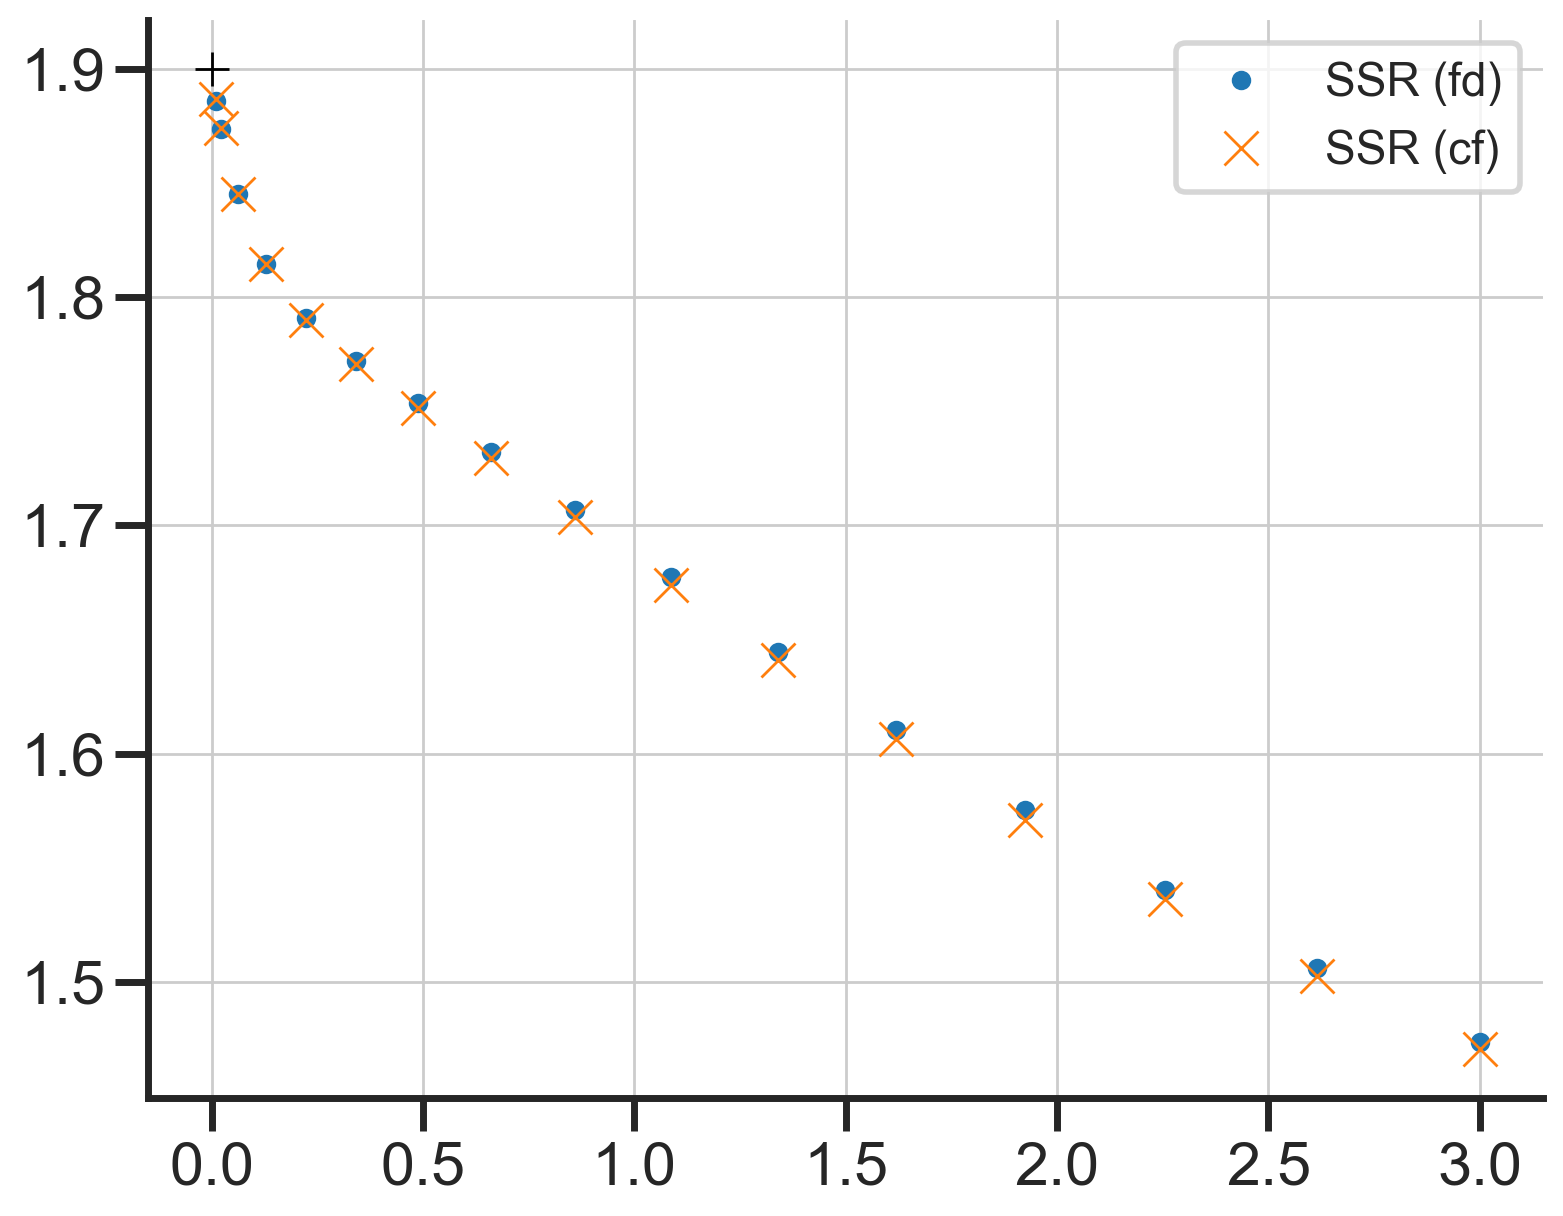

In [35]:
fig, ax = plt.subplots()
ax.plot(Ts, ssr_fd, ".", markersize=12, label="SSR (fd)")
ax.plot(Ts, ssr_cf, "x", markersize=12, label="SSR (cf)")
ax.plot([0], [rheston.H + 3 / 2], "+k")
ax.legend()
plt.show()